<a href="https://colab.research.google.com/github/MayaKusumakar/Team11/blob/Mark-LSTM/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
!pip install -q -U keras-tuner
# Mount Google Drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
file_path = '/content/drive/MyDrive/FakeReviewsProject/data_for_lstm.csv'
df = pd.read_csv(file_path)



Reloading Tuner from fast_tuning/fake_detector/tuner0.json
Epoch 1/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.7976 - loss: 0.3878 - val_accuracy: 0.9382 - val_loss: 0.1617 - learning_rate: 0.0010
Epoch 2/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9464 - loss: 0.1361 - val_accuracy: 0.9468 - val_loss: 0.1476 - learning_rate: 0.0010
Epoch 3/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9684 - loss: 0.0859 - val_accuracy: 0.9498 - val_loss: 0.1593 - learning_rate: 8.0000e-04


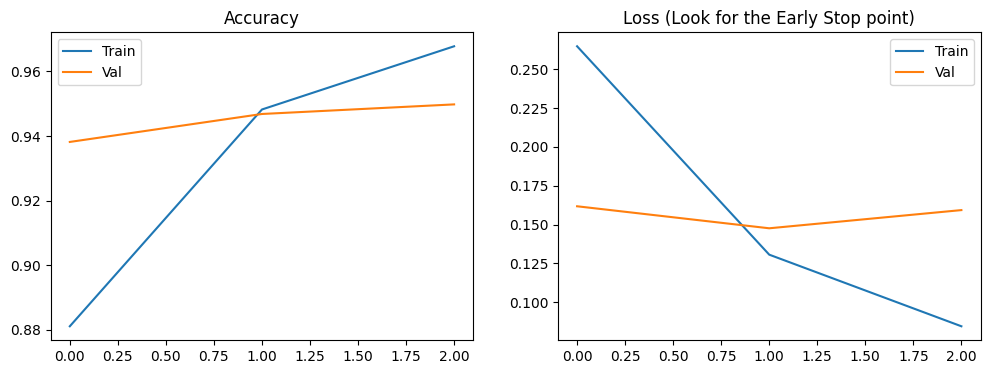

127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Final Metrics:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2022
           1       0.96      0.94      0.95      2022

    accuracy                           0.95      4044
   macro avg       0.95      0.95      0.95      4044
weighted avg       0.95      0.95      0.95      4044



In [18]:
# 1. Install & Imports
!pip install -q -U keras-tuner
import pandas as pd
import numpy as np
import tensorflow as tf
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 80,10,10 Split with strat
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

# Z score scaling for ratings
scaler = StandardScaler()
train_ratings = scaler.fit_transform(train_df[['rating']].values)
val_ratings = scaler.transform(val_df[['rating']].values)
test_ratings = scaler.transform(test_df[['rating']].values)

# Tokenization
MAX_VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 100
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text'].astype(str))

def prepare_sequences(data_frame):
    sequences = tokenizer.texts_to_sequences(data_frame['text'].astype(str))
    return pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

X_train_text = prepare_sequences(train_df)
X_val_text = prepare_sequences(val_df)
X_test_text = prepare_sequences(test_df)

# Dual Scan(checks overall tone and outliers/red flags)


def build_tuned_model(hp):
    text_input = Input(shape=(MAX_SEQUENCE_LENGTH,), name='text_input')
    rating_input = Input(shape=(1,), name='rating_input')

    x = Embedding(MAX_VOCAB_SIZE, hp.Int('embed_dim', 64, 96, step=32))(text_input)
    x = SpatialDropout1D(0.3)(x)
    x = Bidirectional(LSTM(hp.Int('lstm_units', 32, 48, step=16), return_sequences=True))(x)

    # Dual Scan-> Max and Average Pooling
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    text_features = Concatenate()([avg_pool, max_pool])

    r = Dense(8, activation='relu')(rating_input)

    merged = Concatenate()([text_features, r])
    merged = Dropout(0.4)(merged)
    merged = Dense(16, activation='relu')(merged)
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs=[text_input, rating_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# patience = 1 -> stops when val loss gets worse
fast_stopper = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

def lr_decay(epoch, lr):
    return lr if epoch < 2 else lr * 0.8 # Faster decay
lr_scheduler = LearningRateScheduler(lr_decay)

# Quick Parameter tuning
tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_accuracy',
    max_trials=3,
    directory='fast_tuning',
    project_name='fake_detector'
)


tuner.search(
    [X_train_text, train_ratings], train_df['label'].values,
    epochs=5, # Fewer epochs for search
    validation_data=([X_val_text, val_ratings], val_df['label'].values),
    callbacks=[fast_stopper]
)

# Results

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.hypermodel.build(best_hps)

history = final_model.fit(
    [X_train_text, train_ratings], train_df['label'].values,
    epochs=10,
    validation_data=([X_val_text, val_ratings], val_df['label'].values),
    callbacks=[fast_stopper, lr_scheduler],
    verbose=1
)

# Visualizations for evaluating model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss (Look for the Early Stop point)')
plt.legend()
plt.show()

# Final detailed check
y_pred = (final_model.predict([X_test_text, test_ratings]) > 0.5).astype(int)
print("\nFinal Metrics:")
print(classification_report(test_df['label'], y_pred))